## Boulevard Hotels Analysis using Pandas (Python)

In [1]:
!mamba install pandas
%pip install openpyxl

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.7035999999940397 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
mambajs 0.19.13

Process pip requirements ...



### 1. EDA: Data Exploration
#### Imported 'Pandas' & all necessary Datasets (.csv files):
- Fact Table: Bookings Data
- Dim Table: Date
- Dim Table: Hotels Data
- Dim Table: Rooms
- Fact Table: Aggregated_booking

In [2]:
import pandas as pd

In [3]:
df_bookings = pd.read_csv('fact_bookings.csv')
df_date = pd.read_csv('dim_date.csv')
df_hotel = pd.read_csv('dim_hotels.csv')
df_rooms = pd.read_csv('dim_rooms.csv')
df_agg_bookings = pd.read_csv('fact_aggregated_bookings.csv')

In [4]:
df_rooms

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [7]:
df_hotel.property_name.value_counts()

property_name
Boulevard Grands     4
Boulevard Exotica    4
Boulevard City       4
Boulevard Blu        4
Boulevard Bay        4
Boulevard Palace     4
Boulevard Seasons    1
Name: count, dtype: int64

In [12]:
df_hotel.head(3)

,property_id,property_name,category,city
0,16558,Boulevard Grands,Luxury,Munich
1,16559,Boulevard Exotica,Luxury,Berlin
2,16560,Boulevard City,Business,Munich


<Axes: title={'center': 'Hotel Counts'}, xlabel='city'>

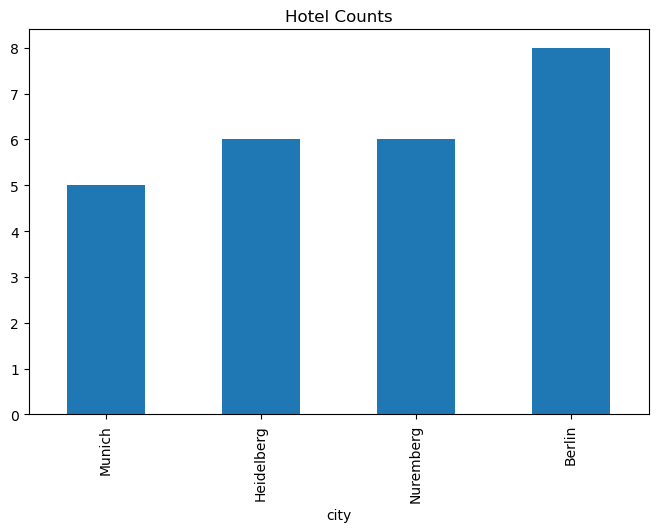

In [16]:
# Display total Hotel counts in each City as 'Bar Chart':
df_hotel.city.value_counts().sort_values().plot(kind = 'bar', title = 'Hotel Counts', figsize=(8,5))

In [23]:
# 'df_bookings' has 1,34,590 rows of records:
df_bookings.head(4)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-2022,01-05-2022,02-05-2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-2022,01-05-2022,04-05-2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-2022,01-05-2022,02-05-2022,-2.0,RT1,others,NaN,Cancelled,9100,3640


In [18]:
df_bookings.shape

(134590, 12)

In [19]:
df_bookings.room_category.unique()

<StringArray>
['RT1', 'RT2', 'RT3', 'RT4']
Length: 4, dtype: str

In [20]:
df_bookings.booking_platform.unique()

<StringArray>
[ 'direct online',         'others',        'logtrip',       'tripster',
   'makeyourtrip',        'journey', 'direct offline']
Length: 7, dtype: str

In [75]:
df_bookings.booking_platform.value_counts()

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

<Axes: title={'center': 'Booking Platform'}, xlabel='booking_platform'>

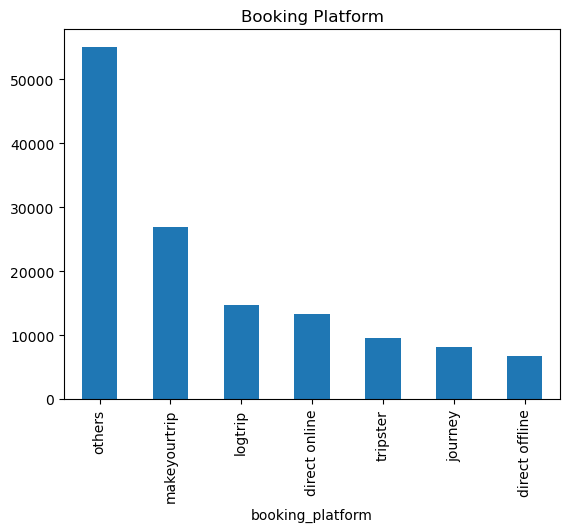

In [21]:
df_bookings.booking_platform.value_counts().plot( kind = 'bar', title = 'Booking Platform')

In [24]:
# 'df_agg_bookings' has 9200 rows of records:
df_agg_bookings.head(4)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,01-May-22,RT1,25,30.0
1,19562,01-May-22,RT1,28,30.0
2,19563,01-May-22,RT1,23,30.0
3,17558,01-May-22,RT1,30,19.0


#### Important Insights:

In [25]:
# Unique property IDs in aggregate bookings dataset:
df_agg_bookings.property_id.unique()

array([16559, 19562, 19563, 17558, 16558, 17560, 19558, 19560, 17561,
       16560, 16561, 16562, 16563, 17559, 17562, 17563, 18558, 18559,
       18561, 18562, 18563, 19559, 19561, 17564, 18560], dtype=int64)

In [26]:
# Total number of bookings per property_id:
df_agg_bookings.groupby("property_id")["successful_bookings"].sum()

property_id
16558    3153
16559    7338
16560    4693
16561    4418
16562    4820
16563    7211
17558    5053
17559    6142
17560    6013
17561    5183
17562    3424
17563    6337
17564    3982
18558    4475
18559    5256
18560    6638
18561    6458
18562    7333
18563    4737
19558    4400
19559    4729
19560    6079
19561    5736
19562    5812
19563    5413
Name: successful_bookings, dtype: int64

In [27]:
# The days on which bookings are greater than capacity:
df_agg_bookings[df_agg_bookings.successful_bookings > df_agg_bookings.capacity]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,01-May-22,RT1,30,19.0
12,16563,01-May-22,RT1,100,41.0
4136,19558,11-Jun-22,RT2,50,39.0
6209,19560,02-Jul-22,RT1,123,26.0
8522,19559,25-Jul-22,RT1,35,24.0
9194,18563,31-Jul-22,RT4,20,18.0


In [45]:
# The properties that have the highest capacity:
df_agg_bookings.capacity.max()

np.float64(50.0)

### 2. Data Cleaning:
- Removal of (-ve) signs by using the absolute method (abs)
- Dropped a record with ID 'Jun082218562RT12' to remove an anomaly (Recorded 17 guests in RT1 room)
- Removed records where 'revenue_generated' values exceeded the higher limit. 

In [46]:
# Errors in the 'df_booking' dataset:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134589.000000,134586.000000,56683.000000,1.345890e+05,134589.000000
mean,18061.109771,2.036935,3.619004,1.537812e+04,12696.169293
std,1093.059055,1.032357,1.235009,9.303638e+04,6928.113275
min,16558.000000,1.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,12.000000,5.000000,2.856000e+07,45220.000000


In [47]:
# A lot of (-ve) values in 'no_guests' column:
df_with_negative = df_bookings [df_bookings.no_guests <= 0]
df_with_negative

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized


In [37]:
# Removed the (-ve) by using the absolute method (abs):
df_bookings['no_guests'] = df_bookings['no_guests'].abs()

In [38]:
# No negative values:
df_bookings [df_bookings.no_guests <= 0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized


In [40]:
# An anomaly - Index no. '56715' records 17 guests in room RT1:
df_bookings.head(56718)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-2022,01-05-2022,02-05-2022,3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-2022,01-05-2022,04-05-2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-2022,01-05-2022,02-05-2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
...,...,...,...,...,...,...,...,...,...,...,...,...
56713,Jun082218561RT45,18561,01-06-2022,08-06-2022,14-06-2022,2.0,RT4,logtrip,5.0,Checked Out,19000,19000
56714,Jun082218562RT11,18562,04-06-2022,08-06-2022,14-06-2022,4.0,RT1,others,4.0,Checked Out,7800,7800
56716,Jun082218562RT13,18562,03-06-2022,08-06-2022,09-06-2022,2.0,RT1,others,NaN,Checked Out,6500,6500
56717,Jun082218562RT14,18562,07-06-2022,08-06-2022,13-06-2022,2.0,RT1,others,NaN,Checked Out,6500,6500


In [41]:
# Dropped booking_id 'Jun082218562RT12' as it records 17 guests in room RT1, which is an anomaly: 
df_bookings = df_bookings.drop(df_bookings[df_bookings['booking_id'] == 'Jun082218562RT12'].index)

In [42]:
df_bookings.head(56718)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-2022,01-05-2022,02-05-2022,3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-2022,01-05-2022,04-05-2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-2022,01-05-2022,02-05-2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
...,...,...,...,...,...,...,...,...,...,...,...,...
56713,Jun082218561RT45,18561,01-06-2022,08-06-2022,14-06-2022,2.0,RT4,logtrip,5.0,Checked Out,19000,19000
56714,Jun082218562RT11,18562,04-06-2022,08-06-2022,14-06-2022,4.0,RT1,others,4.0,Checked Out,7800,7800
56716,Jun082218562RT13,18562,03-06-2022,08-06-2022,09-06-2022,2.0,RT1,others,NaN,Checked Out,6500,6500
56717,Jun082218562RT14,18562,07-06-2022,08-06-2022,13-06-2022,2.0,RT1,others,NaN,Checked Out,6500,6500


In [48]:
# One record removed, which was an anomaly 'no_guests' was 17: 
df_bookings.shape

(134589, 12)

In [50]:
# Anomaly detected in 'revenue_generated' column: 'Max (single) Revenue Generated is 2.85 Crs, which is an anomaly' 
df_bookings.revenue_generated.min(), df_bookings.revenue_generated.max()

(np.int64(6500), np.int64(28560000))

In [51]:
# Mean(Avg) Value is '15378.12' & Std deviation is '93036':
mean, std = df_bookings.revenue_generated.mean(), df_bookings.revenue_generated.std()
mean, std

(np.float64(15378.120091537941), np.float64(93036.38115567002))

In [52]:
# Higher limit of Std is '2,94,487' & Lower limit is not considered as it will be (-ve). Revenue can't be in (-ve):
higher_lmt = mean + (3*std) 
higher_lmt

np.float64(294487.263558548)

In [54]:
# We have 5 records that exceed the higher limit. So, considering those records as anomalies: 
limit_exceeds = df_bookings [df_bookings.revenue_generated > higher_lmt]
limit_exceeds

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012216558RT13,16558,28-04-2022,01-05-2022,04-05-2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
111,May012216559RT32,16559,29-04-2022,01-05-2022,02-05-2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
315,May012216562RT22,16562,28-04-2022,01-05-2022,04-05-2022,2.0,RT2,direct offline,3.0,Checked Out,12600000,12600
562,May012217559RT118,17559,26-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,2000000,4420
129176,Jul282216562RT26,16562,21-07-2022,28-07-2022,29-07-2022,2.0,RT2,direct online,3.0,Checked Out,10000000,12600


In [55]:
# New record after removing 5 anomalies that exceeded the higher limit:  
df_bookings = df_bookings [df_bookings.revenue_generated < higher_lmt]
df_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-2022,01-05-2022,02-05-2022,3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640
3,May012216558RT14,16558,28-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-2022,01-05-2022,02-05-2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,01-05-2022,01-05-2022,03-05-2022,2.0,RT1,others,4.0,Checked Out,9100,9100
...,...,...,...,...,...,...,...,...,...,...,...,...
134585,Jul312217564RT46,17564,29-07-2022,31-07-2022,03-08-2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134586,Jul312217564RT47,17564,30-07-2022,31-07-2022,01-08-2022,4.0,RT4,logtrip,2.0,Checked Out,38760,38760
134587,Jul312217564RT48,17564,30-07-2022,31-07-2022,02-08-2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-2022,31-07-2022,01-08-2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [56]:
df_bookings.shape

(134584, 12)

In [57]:
df_bookings.revenue_realized.describe()

count    134584.000000
mean      12696.141064
std        6928.063343
min        2600.000000
25%        7600.000000
50%       11700.000000
75%       15300.000000
max       45220.000000
Name: revenue_realized, dtype: float64

In [58]:
df_bookings [df_bookings.revenue_realized > 34000]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
137,May012216559RT41,16559,27-04-2022,01-05-2022,07-05-2022,4.0,RT4,others,NaN,Checked Out,38760,38760
139,May012216559RT43,16559,01-05-2022,01-05-2022,02-05-2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220
143,May012216559RT47,16559,28-04-2022,01-05-2022,03-05-2022,3.0,RT4,others,5.0,Checked Out,35530,35530
149,May012216559RT413,16559,24-04-2022,01-05-2022,07-05-2022,5.0,RT4,logtrip,NaN,Checked Out,41990,41990
222,May012216560RT45,16560,30-04-2022,01-05-2022,03-05-2022,5.0,RT4,others,3.0,Checked Out,34580,34580
...,...,...,...,...,...,...,...,...,...,...,...,...
134331,Jul312219560RT412,19560,31-07-2022,31-07-2022,01-08-2022,6.0,RT4,others,2.0,Checked Out,39900,39900
134467,Jul312219562RT45,19562,28-07-2022,31-07-2022,01-08-2022,6.0,RT4,makeyourtrip,4.0,Checked Out,39900,39900
134474,Jul312219562RT412,19562,25-07-2022,31-07-2022,06-08-2022,5.0,RT4,direct offline,5.0,Checked Out,37050,37050
134581,Jul312217564RT42,17564,31-07-2022,31-07-2022,01-08-2022,4.0,RT4,makeyourtrip,4.0,Checked Out,38760,38760


In [59]:
# High Rev_realized of '34,000 & above' are for 'RT4' Presidential suites':
df_bookings [df_bookings.room_category == 'RT4'].revenue_realized.describe()

count    16073.000000
mean     23440.103652
std       9048.865206
min       7600.000000
25%      19000.000000
50%      26600.000000
75%      32300.000000
max      45220.000000
Name: revenue_realized, dtype: float64

In [60]:
# Lots of NaN values for 'ratings_given', but it's fine. Not everyone who visits the hotel gives rating: 
df_bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                3
room_category            0
booking_platform         0
ratings_given        77904
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

In [122]:
# Final cleaned dataset for df_bookings
df_bookings.shape

(134584, 12)

In [126]:
# Save the file as 'fact_booking_data.csv':
df_bookings.to_csv('fact_booking_data.csv', index = False)

#### Some more Data cleaning:

In [63]:
# Some columns in 'Aggregate bookings' has null values. Fill these with appropriate substitutes:
df_agg_bookings.isnull().sum()

# Capacity column has 2 null values.

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               2
dtype: int64

In [64]:
df_agg_bookings.capacity.median()

np.float64(25.0)

In [65]:
# Replacing the 2 'NaN' values with 25.0:
df_agg_bookings['capacity'] = df_agg_bookings['capacity'].fillna(25.0)

In [66]:
df_agg_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               0
dtype: int64

In [67]:
df_agg_bookings.loc[[8,15]]

,property_id,check_in_date,room_category,successful_bookings,capacity
8,17561,01-May-22,RT1,22,25.0
15,17563,01-May-22,RT1,21,25.0


In [68]:
df_agg_bookings

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,01-May-22,RT1,25,30.0
1,19562,01-May-22,RT1,28,30.0
2,19563,01-May-22,RT1,23,30.0
3,17558,01-May-22,RT1,30,19.0
4,16558,01-May-22,RT1,18,19.0
...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0
9196,16559,31-Jul-22,RT4,13,18.0
9197,17558,31-Jul-22,RT4,3,6.0
9198,19563,31-Jul-22,RT4,3,6.0


In [69]:
# In 'Aggregate bookings', filter out the records that have a successful_bookings value greater than capacity.

df_agg_bookings[df_agg_bookings.successful_bookings > df_agg_bookings.capacity]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,01-May-22,RT1,30,19.0
12,16563,01-May-22,RT1,100,41.0
4136,19558,11-Jun-22,RT2,50,39.0
6209,19560,02-Jul-22,RT1,123,26.0
8522,19559,25-Jul-22,RT1,35,24.0
9194,18563,31-Jul-22,RT4,20,18.0


### 3. Data Transformation:

In [70]:
df_agg_bookings.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,01-May-22,RT1,25,30.0
1,19562,01-May-22,RT1,28,30.0
2,19563,01-May-22,RT1,23,30.0


In [71]:
# Add an 'Occupancy Percentage' column: "successful_bookings / capacity"
df_agg_bookings['occ_pct'] = df_agg_bookings.apply(lambda row: row['successful_bookings']/row['capacity'], axis=1)

# Rounding off into Percentag %:
df_agg_bookings['occ_pct'] = df_agg_bookings['occ_pct'].apply(lambda x: round(x*100, 2))

In [72]:
df_agg_bookings.head(6)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,01-May-22,RT1,25,30.0,83.33
1,19562,01-May-22,RT1,28,30.0,93.33
2,19563,01-May-22,RT1,23,30.0,76.67
3,17558,01-May-22,RT1,30,19.0,157.89
4,16558,01-May-22,RT1,18,19.0,94.74
5,17560,01-May-22,RT1,28,40.0,70.00


### 4. Insight Generations:

#### Avearge Occupancy Rate per Room Category:

In [73]:
# Average occupancy rate in each of the room categories - RT1, RT2, RT3, RT4:
df_agg_bookings.groupby('room_category')['occ_pct'].mean().round(2)

room_category
RT1    58.23
RT2    58.04
RT3    58.03
RT4    59.30
Name: occ_pct, dtype: float64

In [74]:
df_rooms

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


#### Merging Dataset:

In [75]:
# Will merge 2 datasets 'df_room', 'df_agg_booking', so that we get occupancy rate based on 'room_class':
df_merge = pd.merge(df_agg_bookings, df_rooms, left_on = 'room_category', right_on ='room_id')
df_merge.head(6)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class
0,16559,01-May-22,RT1,25,30.0,83.33,RT1,Standard
1,19562,01-May-22,RT1,28,30.0,93.33,RT1,Standard
2,19563,01-May-22,RT1,23,30.0,76.67,RT1,Standard
3,17558,01-May-22,RT1,30,19.0,157.89,RT1,Standard
4,16558,01-May-22,RT1,18,19.0,94.74,RT1,Standard
5,17560,01-May-22,RT1,28,40.0,70.00,RT1,Standard


In [76]:
# Removed (drop) the column 'room_id':
df_merge = df_merge.drop(columns=['room_id'])

In [77]:
df_merge

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class
0,16559,01-May-22,RT1,25,30.0,83.33,Standard
1,19562,01-May-22,RT1,28,30.0,93.33,Standard
2,19563,01-May-22,RT1,23,30.0,76.67,Standard
3,17558,01-May-22,RT1,30,19.0,157.89,Standard
4,16558,01-May-22,RT1,18,19.0,94.74,Standard
...,...,...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0,72.22,Presidential
9196,16559,31-Jul-22,RT4,13,18.0,72.22,Presidential
9197,17558,31-Jul-22,RT4,3,6.0,50.00,Presidential
9198,19563,31-Jul-22,RT4,3,6.0,50.00,Presidential


In [78]:
df_merge.groupby('room_class')['occ_pct'].mean().round(2)

room_class
Elite           58.04
Premium         58.03
Presidential    59.30
Standard        58.23
Name: occ_pct, dtype: float64

#### Average Occupancy Rate per City:

In [79]:
df_hotel.head(6)

,property_id,property_name,category,city
0,16558,Boulevard Grands,Luxury,Munich
1,16559,Boulevard Exotica,Luxury,Berlin
2,16560,Boulevard City,Business,Munich
3,16561,Boulevard Blu,Luxury,Munich
4,16562,Boulevard Bay,Luxury,Munich
5,16563,Boulevard Palace,Business,Munich


In [80]:
df_merge_1 = pd.merge(df_merge, df_hotel, on = 'property_id')

In [127]:
# Save 'df_merge_1' to CSV without date table:
df_merge_1.to_csv('fact_agg_data.csv', index = False)

In [81]:
df_merge_1

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city
0,16559,01-May-22,RT1,25,30.0,83.33,Standard,Boulevard Exotica,Luxury,Berlin
1,19562,01-May-22,RT1,28,30.0,93.33,Standard,Boulevard Bay,Luxury,Nuremberg
2,19563,01-May-22,RT1,23,30.0,76.67,Standard,Boulevard Palace,Business,Nuremberg
3,17558,01-May-22,RT1,30,19.0,157.89,Standard,Boulevard Grands,Luxury,Berlin
4,16558,01-May-22,RT1,18,19.0,94.74,Standard,Boulevard Grands,Luxury,Munich
...,...,...,...,...,...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0,72.22,Presidential,Boulevard Palace,Business,Munich
9196,16559,31-Jul-22,RT4,13,18.0,72.22,Presidential,Boulevard Exotica,Luxury,Berlin
9197,17558,31-Jul-22,RT4,3,6.0,50.00,Presidential,Boulevard Grands,Luxury,Berlin
9198,19563,31-Jul-22,RT4,3,6.0,50.00,Presidential,Boulevard Palace,Business,Nuremberg


<Axes: title={'center': 'Avg. Occupancy per City'}, xlabel='city'>

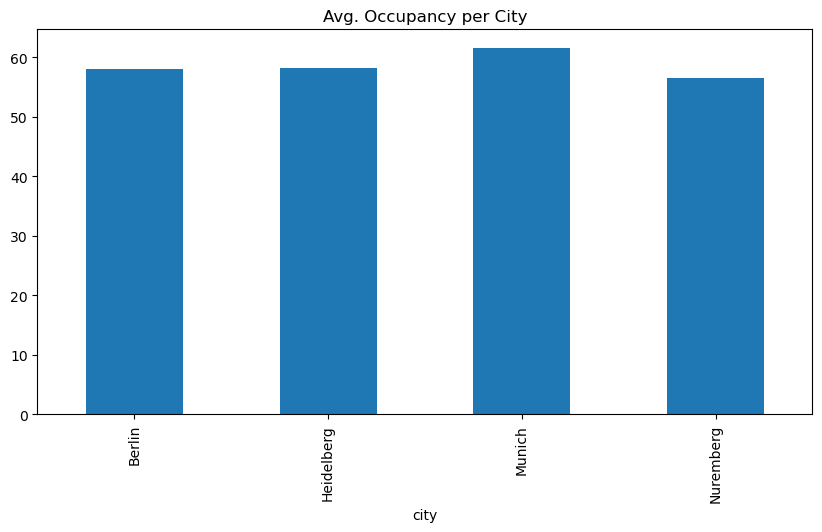

In [83]:
# Average Occupancy rate per City:
df_merge_1.groupby('city')['occ_pct'].mean().plot(kind = 'bar', title = 'Avg. Occupancy per City', figsize=(10,5))

#### Insights: When does the 'Boulevard Hotel' achieve better occupancy - Weekday or Weekends ?

In [84]:
df_date.head(6)

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday
5,06-May-22,May 22,W 19,weekeday


In [85]:
# So, for that, we will merge the 'df_date' and 'df_merge_1' datasets based on Date:

df_merge_2 = pd.merge(df_merge_1, df_date, left_on = 'check_in_date', right_on ='date')
df_merge_2.head(6)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city,date,mmm yy,week no,day_type
0,16559,01-May-22,RT1,25,30.0,83.33,Standard,Boulevard Exotica,Luxury,Berlin,01-May-22,May 22,W 19,weekend
1,19562,01-May-22,RT1,28,30.0,93.33,Standard,Boulevard Bay,Luxury,Nuremberg,01-May-22,May 22,W 19,weekend
2,19563,01-May-22,RT1,23,30.0,76.67,Standard,Boulevard Palace,Business,Nuremberg,01-May-22,May 22,W 19,weekend
3,17558,01-May-22,RT1,30,19.0,157.89,Standard,Boulevard Grands,Luxury,Berlin,01-May-22,May 22,W 19,weekend
4,16558,01-May-22,RT1,18,19.0,94.74,Standard,Boulevard Grands,Luxury,Munich,01-May-22,May 22,W 19,weekend
5,17560,01-May-22,RT1,28,40.0,70.00,Standard,Boulevard City,Business,Berlin,01-May-22,May 22,W 19,weekend


In [86]:
df_merge_2.groupby('day_type')['occ_pct'].mean().round(2)

day_type
weekeday    51.82
weekend     74.24
Name: occ_pct, dtype: float64

#### Occupancy for different cities in May, June, July:

In [87]:
df_merge_2['mmm yy'].unique()

<StringArray>
['May 22', 'Jun 22', 'Jul 22']
Length: 3, dtype: str

In [90]:
df_may = df_merge_2[df_merge_2['mmm yy'] == 'May 22']
df_june = df_merge_2[df_merge_2['mmm yy'] == 'Jun 22']
df_july = df_merge_2[df_merge_2['mmm yy'] == 'Jul 22']

df_july.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city,date,mmm yy,week no,day_type
6100,16559,01-Jul-22,RT1,20,30.0,66.67,Standard,Boulevard Exotica,Luxury,Berlin,01-Jul-22,Jul 22,W 27,weekeday
6101,18560,01-Jul-22,RT1,17,30.0,56.67,Standard,Boulevard City,Business,Heidelberg,01-Jul-22,Jul 22,W 27,weekeday
6102,19562,01-Jul-22,RT1,19,30.0,63.33,Standard,Boulevard Bay,Luxury,Nuremberg,01-Jul-22,Jul 22,W 27,weekeday
6103,19563,01-Jul-22,RT1,14,30.0,46.67,Standard,Boulevard Palace,Business,Nuremberg,01-Jul-22,Jul 22,W 27,weekeday
6104,17558,01-Jul-22,RT1,9,19.0,47.37,Standard,Boulevard Grands,Luxury,Berlin,01-Jul-22,Jul 22,W 27,weekeday


In [93]:
# Occupancy for different cities in 'May':
df_may.groupby('city')['occ_pct'].mean().round(2).sort_values()

city
Nuremberg     57.09
Berlin        58.53
Heidelberg    59.01
Munich        62.10
Name: occ_pct, dtype: float64

In [94]:
# Occupancy for different cities in 'June':
df_june.groupby('city')['occ_pct'].mean().round(2).sort_values()

city
Nuremberg     55.95
Heidelberg    57.69
Berlin        57.79
Munich        61.46
Name: occ_pct, dtype: float64

In [95]:
# Occupancy for different cities in 'July':
df_july.groupby('city')['occ_pct'].mean().round(2).sort_values()

city
Nuremberg     56.72
Berlin        57.50
Heidelberg    57.72
Munich        61.25
Name: occ_pct, dtype: float64

#### New updated data for the month of August:
- Append that to existing data

In [96]:
df_aug = pd.read_csv('new_data_august.csv')
df_aug

,property_id,property_name,category,city,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ_pct
0,16559,Boulevard Exotica,Luxury,Berlin,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,30,100.00
1,19562,Boulevard Bay,Luxury,Nuremberg,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,21,30,70.00
2,19563,Boulevard Palace,Business,Nuremberg,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,23,30,76.67
3,19558,Boulevard Grands,Luxury,Nuremberg,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,40,75.00
4,19560,Boulevard City,Business,Nuremberg,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,20,26,76.92
5,17561,Boulevard Blu,Luxury,Berlin,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,18,26,69.23
6,17564,Boulevard Seasons,Business,Berlin,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,10,16,62.50


In [97]:
df_aug.shape

(7, 13)

In [98]:
df_merge_2.shape

(9200, 14)

In [99]:
updated_df = pd.concat([df_merge_2, df_aug], ignore_index = True, axis = 0)

In [100]:
updated_df.tail(10)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city,date,mmm yy,week no,day_type
9197,17558,31-Jul-22,RT4,3,6.0,50.00,Presidential,Boulevard Grands,Luxury,Berlin,31-Jul-22,Jul 22,W 32,weekend
9198,19563,31-Jul-22,RT4,3,6.0,50.00,Presidential,Boulevard Palace,Business,Nuremberg,31-Jul-22,Jul 22,W 32,weekend
9199,17561,31-Jul-22,RT4,3,4.0,75.00,Presidential,Boulevard Blu,Luxury,Berlin,31-Jul-22,Jul 22,W 32,weekend
9200,16559,01-Aug-22,RT1,30,30.0,100.00,Standard,Boulevard Exotica,Luxury,Berlin,NaN,Aug-22,W 32,weekeday
9201,19562,01-Aug-22,RT1,21,30.0,70.00,Standard,Boulevard Bay,Luxury,Nuremberg,NaN,Aug-22,W 32,weekeday
9202,19563,01-Aug-22,RT1,23,30.0,76.67,Standard,Boulevard Palace,Business,Nuremberg,NaN,Aug-22,W 32,weekeday
9203,19558,01-Aug-22,RT1,30,40.0,75.00,Standard,Boulevard Grands,Luxury,Nuremberg,NaN,Aug-22,W 32,weekeday
9204,19560,01-Aug-22,RT1,20,26.0,76.92,Standard,Boulevard City,Business,Nuremberg,NaN,Aug-22,W 32,weekeday
9205,17561,01-Aug-22,RT1,18,26.0,69.23,Standard,Boulevard Blu,Luxury,Berlin,NaN,Aug-22,W 32,weekeday
9206,17564,01-Aug-22,RT1,10,16.0,62.50,Standard,Boulevard Seasons,Business,Berlin,NaN,Aug-22,W 32,weekeday


In [129]:
# Save file to csv:
updated_df.to_csv('update_agg_data.csv', index = False)

# df_all.to_excel('zz.xlsx', index = False)

#### Revenue realized per city:

In [101]:
df_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-2022,01-05-2022,02-05-2022,3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640
3,May012216558RT14,16558,28-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-2022,01-05-2022,02-05-2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,01-05-2022,01-05-2022,03-05-2022,2.0,RT1,others,4.0,Checked Out,9100,9100
...,...,...,...,...,...,...,...,...,...,...,...,...
134585,Jul312217564RT46,17564,29-07-2022,31-07-2022,03-08-2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134586,Jul312217564RT47,17564,30-07-2022,31-07-2022,01-08-2022,4.0,RT4,logtrip,2.0,Checked Out,38760,38760
134587,Jul312217564RT48,17564,30-07-2022,31-07-2022,02-08-2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-2022,31-07-2022,01-08-2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [102]:
df_hotel.head()

,property_id,property_name,category,city
0,16558,Boulevard Grands,Luxury,Munich
1,16559,Boulevard Exotica,Luxury,Berlin
2,16560,Boulevard City,Business,Munich
3,16561,Boulevard Blu,Luxury,Munich
4,16562,Boulevard Bay,Luxury,Munich


In [103]:
df_all_booking = pd.merge(df_bookings, df_hotel, on = 'property_id')
df_all_booking.head(4)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT11,16558,27-04-2022,01-05-2022,02-05-2022,3.0,RT1,direct online,1.0,Checked Out,10010,10010,Boulevard Grands,Luxury,Munich
1,May012216558RT12,16558,30-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Boulevard Grands,Luxury,Munich
2,May012216558RT14,16558,28-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Boulevard Grands,Luxury,Munich
3,May012216558RT15,16558,27-04-2022,01-05-2022,02-05-2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Boulevard Grands,Luxury,Munich


In [104]:
df_all_booking.groupby('city')['revenue_realized'].sum().sort_values()

city
Munich        294466018
Heidelberg    325226370
Nuremberg     420397050
Berlin        668608011
Name: revenue_realized, dtype: int64

#### Print Month by Month revenue:

In [105]:
df_all_booking.head(4)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT11,16558,27-04-2022,01-05-2022,02-05-2022,3.0,RT1,direct online,1.0,Checked Out,10010,10010,Boulevard Grands,Luxury,Munich
1,May012216558RT12,16558,30-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Boulevard Grands,Luxury,Munich
2,May012216558RT14,16558,28-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Boulevard Grands,Luxury,Munich
3,May012216558RT15,16558,27-04-2022,01-05-2022,02-05-2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Boulevard Grands,Luxury,Munich


In [106]:
df_date['mmm yy'].unique()

<StringArray>
['May 22', 'Jun 22', 'Jul 22']
Length: 3, dtype: str

In [107]:
df_date.head(4)

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday


In [108]:
df_all_booking.info()

<class 'pandas.DataFrame'>
RangeIndex: 134584 entries, 0 to 134583
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134584 non-null  str    
 1   property_id        134584 non-null  int64  
 2   booking_date       134584 non-null  str    
 3   check_in_date      134584 non-null  str    
 4   checkout_date      134584 non-null  str    
 5   no_guests          134581 non-null  float64
 6   room_category      134584 non-null  str    
 7   booking_platform   134584 non-null  str    
 8   ratings_given      56680 non-null   float64
 9   booking_status     134584 non-null  str    
 10  revenue_generated  134584 non-null  int64  
 11  revenue_realized   134584 non-null  int64  
 12  property_name      134584 non-null  str    
 13  category           134584 non-null  str    
 14  city               134584 non-null  str    
dtypes: float64(2), int64(3), str(10)
memory usage: 10.3 MB


In [109]:
df_date['date'] = pd.to_datetime(df_date['date'])
df_date

/tmp/xpython_42/2310970186.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_date['date'] = pd.to_datetime(df_date['date'])


,date,mmm yy,week no,day_type
0,2022-05-01,May 22,W 19,weekend
1,2022-05-02,May 22,W 19,weekeday
2,2022-05-03,May 22,W 19,weekeday
3,2022-05-04,May 22,W 19,weekeday
4,2022-05-05,May 22,W 19,weekeday
...,...,...,...,...
87,2022-07-27,Jul 22,W 31,weekeday
88,2022-07-28,Jul 22,W 31,weekeday
89,2022-07-29,Jul 22,W 31,weekeday
90,2022-07-30,Jul 22,W 31,weekend


In [110]:
df_all_booking['check_in_date'] = pd.to_datetime(df_all_booking['check_in_date'], format="%d-%m-%Y")

In [111]:
df_all_booking

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT11,16558,27-04-2022,2022-05-01,02-05-2022,3.0,RT1,direct online,1.0,Checked Out,10010,10010,Boulevard Grands,Luxury,Munich
1,May012216558RT12,16558,30-04-2022,2022-05-01,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Boulevard Grands,Luxury,Munich
2,May012216558RT14,16558,28-04-2022,2022-05-01,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Boulevard Grands,Luxury,Munich
3,May012216558RT15,16558,27-04-2022,2022-05-01,02-05-2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Boulevard Grands,Luxury,Munich
4,May012216558RT16,16558,01-05-2022,2022-05-01,03-05-2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Boulevard Grands,Luxury,Munich
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134579,Jul312217564RT46,17564,29-07-2022,2022-07-31,03-08-2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300,Boulevard Seasons,Business,Berlin
134580,Jul312217564RT47,17564,30-07-2022,2022-07-31,01-08-2022,4.0,RT4,logtrip,2.0,Checked Out,38760,38760,Boulevard Seasons,Business,Berlin
134581,Jul312217564RT48,17564,30-07-2022,2022-07-31,02-08-2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920,Boulevard Seasons,Business,Berlin
134582,Jul312217564RT49,17564,29-07-2022,2022-07-31,01-08-2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300,Boulevard Seasons,Business,Berlin


In [113]:
df_all = pd.merge(df_all_booking, df_date, left_on = 'check_in_date', right_on ='date')
df_all.head(7)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city,date,mmm yy,week no,day_type
0,May012216558RT11,16558,27-04-2022,2022-05-01,02-05-2022,3.0,RT1,direct online,1.0,Checked Out,10010,10010,Boulevard Grands,Luxury,Munich,2022-05-01,May 22,W 19,weekend
1,May012216558RT12,16558,30-04-2022,2022-05-01,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Boulevard Grands,Luxury,Munich,2022-05-01,May 22,W 19,weekend
2,May012216558RT14,16558,28-04-2022,2022-05-01,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Boulevard Grands,Luxury,Munich,2022-05-01,May 22,W 19,weekend
3,May012216558RT15,16558,27-04-2022,2022-05-01,02-05-2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Boulevard Grands,Luxury,Munich,2022-05-01,May 22,W 19,weekend
4,May012216558RT16,16558,01-05-2022,2022-05-01,03-05-2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Boulevard Grands,Luxury,Munich,2022-05-01,May 22,W 19,weekend
5,May012216558RT17,16558,28-04-2022,2022-05-01,06-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Boulevard Grands,Luxury,Munich,2022-05-01,May 22,W 19,weekend
6,May012216558RT18,16558,26-04-2022,2022-05-01,03-05-2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,Boulevard Grands,Luxury,Munich,2022-05-01,May 22,W 19,weekend


In [114]:
df_all.groupby('mmm yy')['revenue_realized'].sum()

mmm yy
Jul 22    572895608
Jun 22    553925855
May 22    581875986
Name: revenue_realized, dtype: int64

In [130]:
# Save the final 'booking_data' into csv:
df_all.to_csv('fact_all_booking.csv', index = False)

#### Insights: Revenue Realized per Hotel

In [117]:
# Revenue realized per hotel :
df_all.property_name.unique()

<StringArray>
[ 'Boulevard Grands', 'Boulevard Exotica',    'Boulevard City',
     'Boulevard Blu',     'Boulevard Bay',  'Boulevard Palace',
 'Boulevard Seasons']
Length: 7, dtype: str

In [118]:
df_all.groupby('property_name')['revenue_realized'].sum().round(2).sort_values()

property_name
Boulevard Seasons     66125495
Boulevard Grands     211523664
Boulevard Bay        260019478
Boulevard Blu        260855522
Boulevard City       285811939
Boulevard Palace     304081863
Boulevard Exotica    320279488
Name: revenue_realized, dtype: int64

In [119]:
# Average rating per city:
df_all.groupby("city")["ratings_given"].mean().round(2)

city
Berlin        3.65
Heidelberg    3.66
Munich        3.78
Nuremberg     3.41
Name: ratings_given, dtype: float64

<Axes: title={'center': 'Revenue from PF'}>

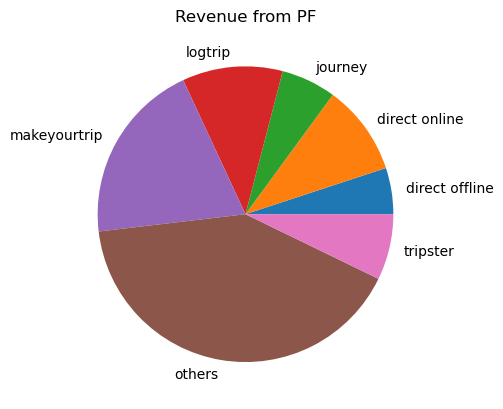

In [120]:
# Revenue realized per booking platform 'Pie Chart':
df_all.groupby("booking_platform")["revenue_realized"].sum().plot(kind="pie", title = 'Revenue from PF')